In [6]:
import pandas as pd
import numpy as np

# For reproducible results
np.random.seed(42)

rows = 200

def create_dataset():
    glucose = np.random.randint(70, 200, rows)
    bp = np.random.randint(50, 110, rows)
    skin = np.random.randint(10, 50, rows)
    insulin = np.random.randint(15, 300, rows)
    bmi = np.round(np.random.uniform(18, 45, rows), 2)
    dpf = np.round(np.random.uniform(0.1, 2.5, rows), 3)
    age = np.random.randint(21, 80, rows)

    # Outcome depends on glucose, BMI and age
    score = (
        (glucose > 140).astype(int)
        + (bmi > 30).astype(int)
        + (age > 45).astype(int)
    )

    outcome = (score >= 2).astype(int)

    return pd.DataFrame({
        "Glucose": glucose,
        "BloodPressure": bp,
        "SkinThickness": skin,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": dpf,
        "Age": age,
        "Outcome": outcome
    })

uci = create_dataset()
pima = create_dataset()

uci.to_csv("uci_diabetes (3).csv", index=False)
pima.to_csv("pima_diabetes (3).csv", index=False)

print("Datasets created successfully.")

Datasets created successfully.


In [7]:
import pandas as pd

uci = pd.read_csv("uci_diabetes (3).csv")
pima = pd.read_csv("pima_diabetes (3).csv")

print("UCI Diabetes Dataset Sample:")
print(uci.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima.head())

UCI Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0      172             84             49       15  37.89   
1      162             65             10       68  33.06   
2       84             90             25      273  33.84   
3      176             85             48      158  33.24   
4      141             82             14       26  28.23   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.124   38        1  
1                     2.019   52        1  
2                     0.939   52        1  
3                     1.224   55        1  
4                     1.600   79        1  

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0       92             91             11      144  36.37   
1      176            100             15      229  19.13   
2      108            100             18      186  20.29   
3      151            107             42      272  37.34   
4      

UCI Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0      172             84             49       15  37.89   
1      162             65             10       68  33.06   
2       84             90             25      273  33.84   
3      176             85             48      158  33.24   
4      141             82             14       26  28.23   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.124   38        1  
1                     2.019   52        1  
2                     0.939   52        1  
3                     1.224   55        1  
4                     1.600   79        1  

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0       92             91             11      144  36.37   
1      176            100             15      229  19.13   
2      108            100             18      186  20.29   
3      151            107             42      272  37.34   
4      

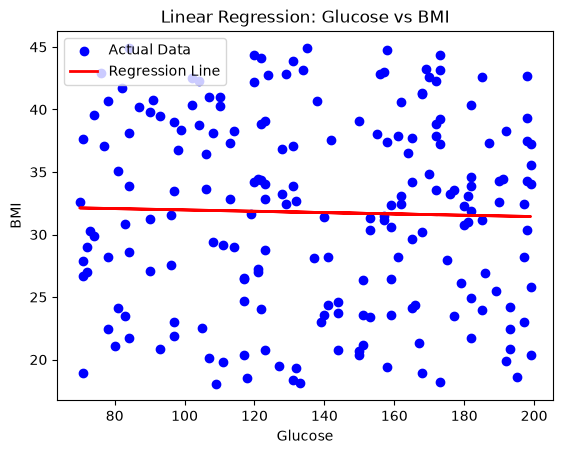


Linear Regression (Predicting BMI using Glucose)
R2 Score: 0.0096


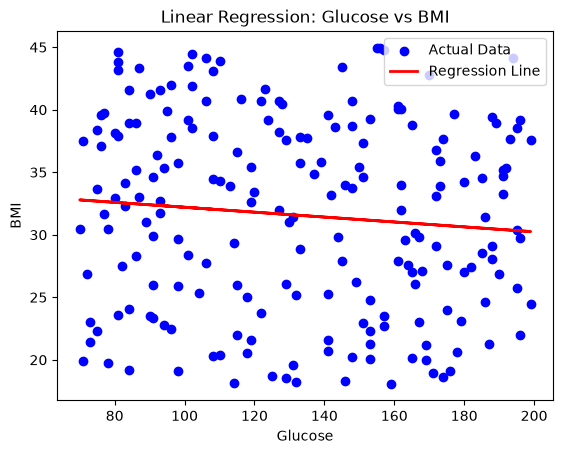


Logistic Regression (Predicting Outcome)
Accuracy Score: 0.9750

Logistic Regression (Predicting Outcome)
Accuracy Score: 0.8250


In [8]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")
pima_diabetes = pd.read_csv("pima_diabetes (3).csv")

# Display first few rows
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())


# Linear Regression Function
def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression (Predicting {y_column} using {x_column})")
    print(f"R2 Score: {r2:.4f}")

    plt.scatter(X, Y, color="blue", label="Actual Data")
    plt.plot(X, Y_pred, color="red", linewidth=2, label="Regression Line")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"Linear Regression: {x_column} vs {y_column}")
    plt.legend()
    plt.show()


# Apply Linear Regression
linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")


# Logistic Regression Function
def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print(f"\nLogistic Regression (Predicting {target})")
    print(f"Accuracy Score: {accuracy:.4f}")


# Features and Target
features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

# Apply Logistic Regression
logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)